Enterprise Data Architecture & Reconciliation
│

├── Business Problem

├── Phase 1: SQL User Status Extraction

├── Phase 2: Server Log Parsing

├── Phase 3: Financial Reconciliation

├── Phase 4: CFO Dashboard

├── Data Quality Report

├── Business Insights

└── Conclusion

## ===================================================================
## PHASE 1: SQL EXTRACTION
## ===================================================================

In [18]:
import sqlite3
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
# Connect to database
conn = sqlite3.connect(r"C:\Users\ANAND\Desktop\istudio\Data Analyst\project\Pedagogical Analysis\datasets and tasks\enterprise_database.db")

query = """
WITH ranked_users AS
(
    SELECT user_id, name, status, updated_at, ROW_NUMBER() OVER
        (
            PARTITION BY user_id
            ORDER BY updated_at DESC
        ) AS rn
    FROM users
)

SELECT user_id, name, status, updated_at
FROM ranked_users
WHERE rn = 1
  AND status = 'Active';
"""

df_active_users = pd.read_sql_query(query, conn)

conn.close()

In [6]:
print(df_active_users.head())

   user_id          name  status           updated_at
0  U-00001  User_U-00001  Active  2023-01-28 14:00:00
1  U-00003  User_U-00003  Active  2023-01-22 14:00:00
2  U-00005  User_U-00005  Active  2023-01-17 14:00:00
3  U-00006  User_U-00006  Active  2023-01-05 14:00:00
4  U-00007  User_U-00007  Active  2023-01-27 14:00:00


In [7]:
print("Active users:", len(df_active_users))

Active users: 14183


## ===================================================================
## PHASE 2: REGEX & UNSTRUCTURED DATA WRANGLING
## ===================================================================

In [25]:
import pandas as pd
import re

# ---------------------------------------------------------------
# 1. LOAD SERVER LOGS
# ---------------------------------------------------------------

logs = pd.read_csv(r"C:\Users\ANAND\Desktop\istudio\Data Analyst\project\Pedagogical Analysis\datasets and tasks\server_logs.txt", header=None, names=["raw_log"])
print("Total raw logs:", len(logs))


Total raw logs: 100001


In [26]:

# ---------------------------------------------------------------
# 2. REMOVE ERROR LOGS
# ---------------------------------------------------------------

logs_clean = logs[~logs["raw_log"].str.contains("ERROR", na=False)].copy()
print("Logs after removing ERROR:", len(logs_clean))

Logs after removing ERROR: 94903


In [27]:
# ---------------------------------------------------------------
# 3. REGEX PATTERN
# ---------------------------------------------------------------
pattern = (
    r'\[(?P<Date>[^\]]+)\].*?'
    r'payload=\{'
    r'"u":"(?P<User_ID>[^"]+)",\s*'
    r'"item_code":"(?P<Product_ID>[^"]+)",\s*'
    r'"eur_val":(?P<Euro_Value>[0-9]+(?:\.[0-9]+)?)'
    r'\}'
)

# ---------------------------------------------------------------
# 4. EXTRACT REQUIRED FIELDS
# ---------------------------------------------------------------

extracted_data = logs_clean["raw_log"].str.extract(pattern, expand=True)


# ---------------------------------------------------------------
# 5. CONVERT DATA TYPES
# ---------------------------------------------------------------

extracted_data["Date"] = pd.to_datetime(extracted_data["Date"], errors="coerce")
extracted_data["Euro_Value"] = pd.to_numeric(extracted_data["Euro_Value"], errors="coerce")


# ---------------------------------------------------------------
# 6. REMOVE INVALID ROWS
# ---------------------------------------------------------------

extracted_data = extracted_data.dropna(
    subset=[
        "Date",
        "User_ID",
        "Product_ID",
        "Euro_Value"
    ]
).reset_index(drop=True)


# ---------------------------------------------------------------
# 7. DISPLAY RESULTS
# ---------------------------------------------------------------

print("\nExtracted data:")
print(extracted_data.head())

print("\nExtracted transactions:", len(extracted_data))

print("\nMissing values:")
print(extracted_data.isna().sum())


Extracted data:
        Date  User_ID Product_ID  Euro_Value
0 2023-03-15  U-19484    PRD-874     3404.44
1 2023-05-09  U-18932    PRD-905     3406.21
2 2023-10-21  U-15882    PRD-284      164.08
3 2023-01-10  U-22781    PRD-665       26.80
4 2023-05-23  U-13348    PRD-589     4964.77

Extracted transactions: 94902

Missing values:
Date          0
User_ID       0
Product_ID    0
Euro_Value    0
dtype: int64


## ===================================================================
## PHASE 3: FINANCIAL RECONCILIATION & MERGING
## ===================================================================

In [28]:
# ---------------------------------------------------------------
# 1. LOAD EXCHANGE RATES
# ---------------------------------------------------------------

exchange_rates = pd.read_csv(r"C:\Users\ANAND\Desktop\istudio\Data Analyst\project\Pedagogical Analysis\datasets and tasks\daily_exchange_rates.csv")

print("Exchange rate rows:", len(exchange_rates))
print(exchange_rates.head())

Exchange rate rows: 365
         Date  EUR_to_USD
0  2023-01-01    1.124836
1  2023-01-02    1.093087
2  2023-01-03    1.132384
3  2023-01-04    1.176151
4  2023-01-05    1.088292


In [29]:
# ---------------------------------------------------------------
# 2. CONVERT DATE COLUMN
# ---------------------------------------------------------------

exchange_rates["Date"] = pd.to_datetime(exchange_rates["Date"], errors="coerce")

# ---------------------------------------------------------------
# 3. SORT BY DATE
# ---------------------------------------------------------------

exchange_rates = (exchange_rates.sort_values("Date").reset_index(drop=True))

# ---------------------------------------------------------------
# 4. CHECK MISSING EXCHANGE RATES
# ---------------------------------------------------------------
print("Missing exchange rates before forward fill:",exchange_rates["EUR_to_USD"].isna().sum())


# ---------------------------------------------------------------
# 5. FORWARD-FILL MISSING RATES
# ---------------------------------------------------------------
exchange_rates["EUR_to_USD"] = (exchange_rates["EUR_to_USD"].ffill())
print("Missing exchange rates after forward fill:",exchange_rates["EUR_to_USD"].isna().sum())


# ---------------------------------------------------------------
# 6. MERGE TRANSACTIONS WITH EXCHANGE RATES
# ---------------------------------------------------------------
df_final = extracted_data.merge(exchange_rates,on="Date",how="left")
print("Rows after exchange-rate merge:",len(df_final))


# ---------------------------------------------------------------
# 7. MERGE WITH ACTIVE USERS
# ---------------------------------------------------------------

df_final = df_final.merge(
    df_active_users[
        ["user_id", "name"]
    ],
    left_on="User_ID",
    right_on="user_id",
    how="inner"
)


# ---------------------------------------------------------------
# 8. CALCULATE USD REVENUE
# ---------------------------------------------------------------
df_final["USD_Revenue"] = (df_final["Euro_Value"] * df_final["EUR_to_USD"])

# ---------------------------------------------------------------
# 9. REMOVE DUPLICATE USER ID COLUMN
# ---------------------------------------------------------------

df_final = df_final.drop(columns=["user_id"])

# ---------------------------------------------------------------
# 10. FINAL VALIDATION
# ---------------------------------------------------------------

print("\nFinal data:")
print(df_final.head())

print("\nFinal rows:", len(df_final))

print("Missing exchange rates:",df_final["EUR_to_USD"].isna().sum())

print("Missing USD revenue:",df_final["USD_Revenue"].isna().sum())

print("Total USD Revenue:",df_final["USD_Revenue"].sum())

Missing exchange rates before forward fill: 104
Missing exchange rates after forward fill: 0
Rows after exchange-rate merge: 94902

Final data:
        Date  User_ID Product_ID  Euro_Value  EUR_to_USD          name  \
0 2023-03-15  U-19484    PRD-874     3404.44    1.178232  User_U-19484   
1 2023-10-21  U-15882    PRD-284      164.08    1.075350  User_U-15882   
2 2023-01-10  U-22781    PRD-665       26.80    1.127128  User_U-22781   
3 2023-10-20  U-22062    PRD-363       48.63    1.075350  User_U-22062   
4 2023-12-02  U-22146    PRD-223      960.60    1.066142  User_U-22146   

   USD_Revenue  
0  4011.220772  
1   176.443420  
2    30.207030  
3    52.294268  
4  1024.135923  

Final rows: 53899
Missing exchange rates: 0
Missing USD revenue: 0
Total USD Revenue: 148274622.90646717


## ===================================================================
## PHASE 4: CFO DASHBOARD & BUSINESS ANALYSIS
## ===================================================================

In [31]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# 1. CREATE MONTH COLUMN
# ---------------------------------------------------------------

df_final["Month"] = (df_final["Date"].dt.to_period("M").astype(str))

# ---------------------------------------------------------------
# 2. TOTAL USD REVENUE BY MONTH
# ---------------------------------------------------------------

monthly_revenue = (df_final.groupby("Month", as_index=False)["USD_Revenue"].sum())

print("MONTHLY USD REVENUE")
print(monthly_revenue)

# ---------------------------------------------------------------
# 3. TOP 5 MOST VALUABLE CUSTOMERS
# ---------------------------------------------------------------

top_5_customers = (df_final.groupby(["User_ID", "name"],as_index=False)["USD_Revenue"].sum().sort_values("USD_Revenue",ascending=False).head(5))

print("\nTOP 5 MOST VALUABLE CUSTOMERS")
print(top_5_customers)


# ---------------------------------------------------------------
# 4. KPI VALUES
# ---------------------------------------------------------------

total_revenue = df_final["USD_Revenue"].sum()
total_transactions = len(df_final)
unique_customers = df_final["User_ID"].nunique()
average_transaction = df_final["USD_Revenue"].mean()

print("\n========== CFO KPIs ==========")
print(f"Total USD Revenue: ${total_revenue:,.2f}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Unique Active Customers: {unique_customers:,}")
print(f"Average Transaction Value: ${average_transaction:,.2f}")


MONTHLY USD REVENUE
      Month   USD_Revenue
0   2023-01  1.284176e+07
1   2023-02  1.143613e+07
2   2023-03  1.234893e+07
3   2023-04  1.201538e+07
4   2023-05  1.233364e+07
5   2023-06  1.208436e+07
6   2023-07  1.244416e+07
7   2023-08  1.281273e+07
8   2023-09  1.222895e+07
9   2023-10  1.250133e+07
10  2023-11  1.258822e+07
11  2023-12  1.263902e+07

TOP 5 MOST VALUABLE CUSTOMERS
       User_ID          name   USD_Revenue
3613   U-06582  User_U-06582  40050.988262
12937  U-23313  User_U-23313  39555.806629
2078   U-03805  User_U-03805  39529.945085
11066  U-20018  User_U-20018  38649.965242
3553   U-06489  User_U-06489  38629.142146

========== CFO KPIs ==========
Total USD Revenue: $148,274,622.91
Total Transactions: 53,899
Unique Active Customers: 13,888
Average Transaction Value: $2,750.97


## ---------------------------------------------------------------
## 5. CREATE DASHBOARD
## ---------------------------------------------------------------

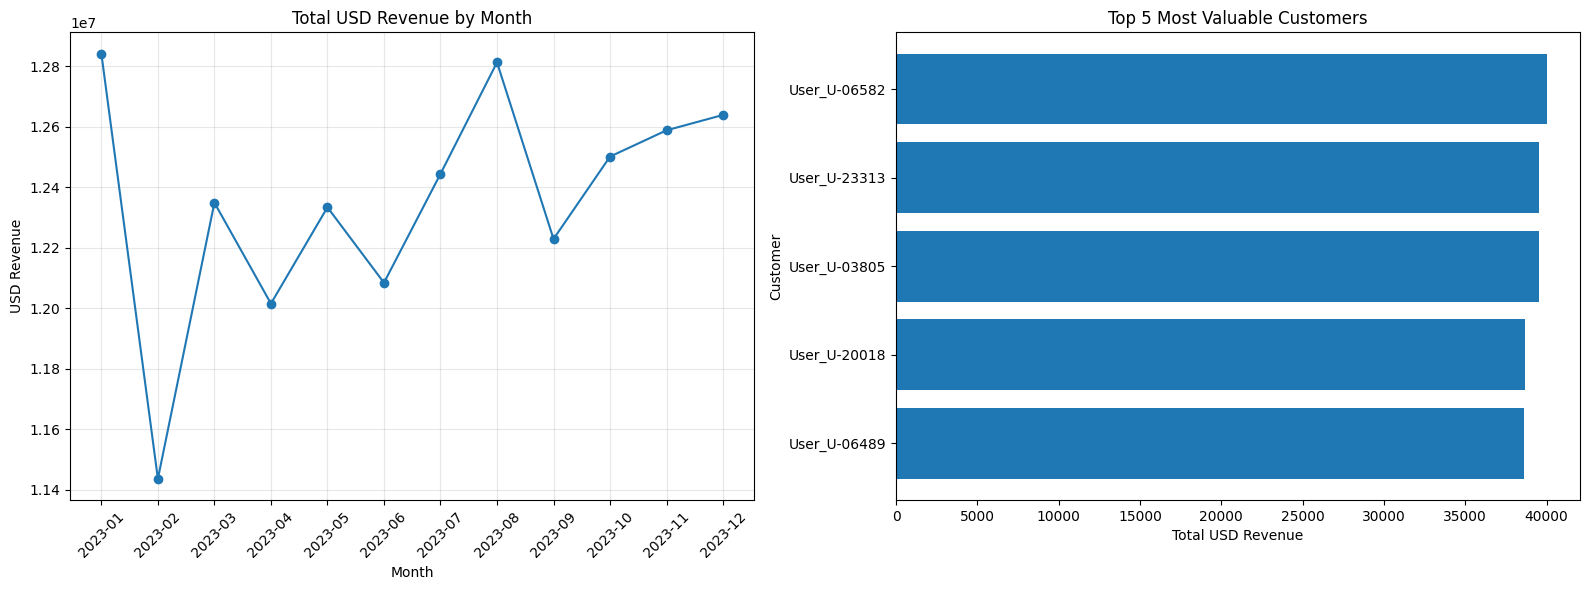

In [36]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)


# ---------------------------------------------------------------
# CHART 1: MONTHLY REVENUE
# ---------------------------------------------------------------

axes[0].plot(
    monthly_revenue["Month"],
    monthly_revenue["USD_Revenue"],
    marker="o"
)

axes[0].set_title(
    "Total USD Revenue by Month"
)

axes[0].set_xlabel("Month")

axes[0].set_ylabel(
    "USD Revenue"
)

axes[0].tick_params(
    axis="x",
    rotation=45
)

axes[0].grid(
    True,
    alpha=0.3
)


# ---------------------------------------------------------------
# CHART 2: TOP 5 CUSTOMERS
# ---------------------------------------------------------------

top_5_plot = (
    top_5_customers
    .sort_values("USD_Revenue")
)

axes[1].barh(
    top_5_plot["name"],
    top_5_plot["USD_Revenue"]
)

axes[1].set_title(
    "Top 5 Most Valuable Customers"
)

axes[1].set_xlabel(
    "Total USD Revenue"
)

axes[1].set_ylabel(
    "Customer"
)


plt.tight_layout()
plt.show()

## ===================================================================
## DATA QUALITY & RECONCILIATION REPORT
## ===================================================================

In [33]:
print("========== DATA QUALITY REPORT ==========")

# Record counts
print(f"Raw log records:              {len(logs):,}")
print(f"ERROR records removed:        {logs['raw_log'].str.contains('ERROR', na=False).sum():,}")
print(f"Valid transactions extracted: {len(extracted_data):,}")
print(f"Latest Active users:          {len(df_active_users):,}")
print(f"Final reconciled transactions:{len(df_final):,}")

# Missing values
print("\n========== MISSING VALUES ==========")
print(df_final.isna().sum())

# Duplicate transactions
duplicate_count = df_final.duplicated(
    subset=[
        "Date",
        "User_ID",
        "Product_ID",
        "Euro_Value"
    ]
).sum()

print("\n========== DUPLICATES ==========")
print(f"Potential duplicate transactions: {duplicate_count:,}")

# Exchange-rate validation
print("\n========== EXCHANGE RATE VALIDATION ==========")
print(
    "Missing exchange rates:",
    df_final["EUR_to_USD"].isna().sum()
)

# Revenue validation
print("\n========== REVENUE VALIDATION ==========")
print(
    f"Total USD Revenue: ${df_final['USD_Revenue'].sum():,.2f}"
)

print(
    f"Average Transaction Value: ${df_final['USD_Revenue'].mean():,.2f}"
)

print("\n========== DATE RANGE ==========")
print("Start date:", df_final["Date"].min())
print("End date:", df_final["Date"].max())

========== DATA QUALITY REPORT ==========
Raw log records:              100,001
ERROR records removed:        5,098
Valid transactions extracted: 94,902
Latest Active users:          14,183
Final reconciled transactions:53,899

========== MISSING VALUES ==========
Date           0
User_ID        0
Product_ID     0
Euro_Value     0
EUR_to_USD     0
name           0
USD_Revenue    0
Month          0
dtype: int64

========== DUPLICATES ==========
Potential duplicate transactions: 0

========== EXCHANGE RATE VALIDATION ==========
Missing exchange rates: 0

========== REVENUE VALIDATION ==========
Total USD Revenue: $148,274,622.91
Average Transaction Value: $2,750.97

========== DATE RANGE ==========
Start date: 2023-01-01 00:00:00
End date: 2023-12-31 00:00:00


## Business Insights

### 1. Overall Revenue

The reconciliation pipeline generated 148.27 million in total USD-equivalent revenue across 53,899 reconciled transactions during 2023.
The average transaction value was approximately 2,750.97.

### 2. Customer Eligibility

The database contained *14,183 users whose latest recorded account status was Active*. Only transactions associated with these currently active users were retained in the final reconciliation dataset.

### 3. Transaction Reconciliation

Out of *94,902 valid transactions extracted from the server logs*, *53,899 transactions* were successfully reconciled with users whose latest status was Active.

### 4. Exchange Rate Handling

The exchange-rate dataset contained *104 missing EUR-to-USD values*. These gaps were resolved using forward-filling based on the most recent available exchange rate. After reconciliation, there were *zero missing exchange rates* in the final dataset.

### 5. Data Quality

The final dataset contained *zero missing values* across all analytical fields and *zero potential duplicate transactions* based on the transaction-level duplicate check.

### 6. Financial Audit Readiness

The final dataset provides a consistent transaction-level view containing the transaction date, user, product, Euro value, applicable EUR-to-USD exchange rate, customer name, and calculated USD revenue. This creates a reliable foundation for the CFO's monthly revenue analysis and customer-value analysis.


## Conclusion

This project successfully integrated data from three different enterprise systems: a historical SQLite user database, unstructured server logs, and a daily EUR-to-USD exchange-rate dataset.

The pipeline used **SQL window functions** to identify the latest status for each user, **vectorized regular expressions** to extract transaction information from 100,000+ server log records, and **date-based data reconciliation** to apply the appropriate exchange rate to each transaction.

After filtering for currently Active users and converting Euro transaction values into USD, the final dataset contained **53,899 reconciled transactions** and approximately **$148.27 million in USD-equivalent revenue**.

The completed analysis provides the CFO with two key views: **monthly USD revenue trends** and the **Top 5 most valuable customers**, while the accompanying data-quality checks confirm that the final dataset contains no missing analytical values, no potential duplicate transactions, and no unresolved exchange-rate gaps.


## CSV File creation for POWER BI dashboard

In [35]:
power_bi_data = df_final[
    [
        "Date",
        "User_ID",
        "name",
        "Product_ID",
        "Euro_Value",
        "EUR_to_USD",
        "USD_Revenue"
    ]
].copy()

# Save Date as date only
power_bi_data["Date"] = pd.to_datetime(power_bi_data["Date"]).dt.date

power_bi_data.to_csv(r"C:\Users\ANAND\Desktop\istudio\Data Analyst\project\Pedagogical Analysis\solution\power_bi_ready_dataset.csv",index=False)

print("File successfully created:")
print("power_bi_ready_dataset.csv")

File successfully created:
power_bi_ready_dataset.csv
